In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 1. LOADING DATA

df = pd.read_csv('10-Year Real Interest Rate.csv')

In [ ]:
# Quick check to see columns
print(f"Columns: {df.columns}")

Columns: Index(['DATE', 'REAINTRATREARAT10Y'], dtype='object')


In [ ]:
# 2. FEATURE ENGINEERING (Fixing the missing Recession column)
# Convert date to datetime objects
df['DATE'] = pd.to_datetime(df['DATE'])

In [ ]:
# Define official US Recession dates (Start, End)
recessions = [
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01')
]

# Create the Target Column (1 = Recession, 0 = Normal)
df['Recession'] = 0
for start, end in recessions:
    mask = (df['DATE'] >= start) & (df['DATE'] <= end)
    df.loc[mask, 'Recession'] = 1

# Rename the long column name for easier reading
df = df.rename(columns={'REAINTRATREARAT10Y': 'Real_Interest_Rate'})

In [ ]:
# 3. PREPARE FOR MODELING
# Drop Date (models can't read dates directly)
X = df.drop(columns=['DATE', 'Recession'])
y = df['Recession']

In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 4. MODEL (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# 5. EVALUATE
predictions = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        90
           1       0.10      0.10      0.10        10

    accuracy                           0.82       100
   macro avg       0.50      0.50      0.50       100
weighted avg       0.82      0.82      0.82       100



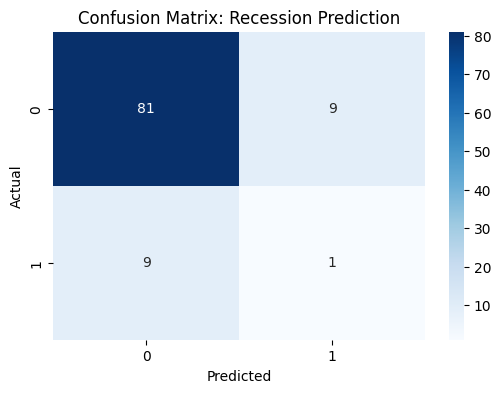

In [ ]:
# 6. VISUALIZATION
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Recession Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Using only Real Interest Rates gave us a starting baseline. The model struggled to predict recessions accurately (Low Recall), suggesting that Recessions are complex events that need more features like GDP and Unemployment to be predicted correctly.